<a href="https://colab.research.google.com/github/K-Sai-2005/EDGE-AI-RISCV/blob/main/CrackDetection_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
!pip install kaggle -q
from google.colab import files
files.upload()    # upload your kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification

# Create the target directory if it doesn't exist
if not os.path.exists('python_training/data'):
    os.makedirs('python_training/data')

!unzip -q concrete-crack-images-for-classification.zip -d python_training/data/

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 233M/233M [00:01<00:00, 142MB/s]



In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────
IMG_SIZE    = 64          # resize to 64×64 (fits in 16KB SRAM pipeline)
BATCH_SIZE  = 32
EPOCHS      = 10
DATA_DIR = './python_training/data'   # place Positive/ and Negative/ folders here
MODEL_PATH  = './crack_model.keras'
TFLITE_PATH = './crack_model_quant.tflite'
C_HEADER    = '../riscv_firmware/model_params.h'
C_SOURCE    = '../riscv_firmware/model_params.c'
# ────────────────────────────────────────────────────────

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


In [3]:


# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print(f'Class mapping: {train_gen.class_indices}')
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.
Class mapping: {'Negative': 0, 'Positive': 1}
Training samples  : 32000
Validation samples: 8000


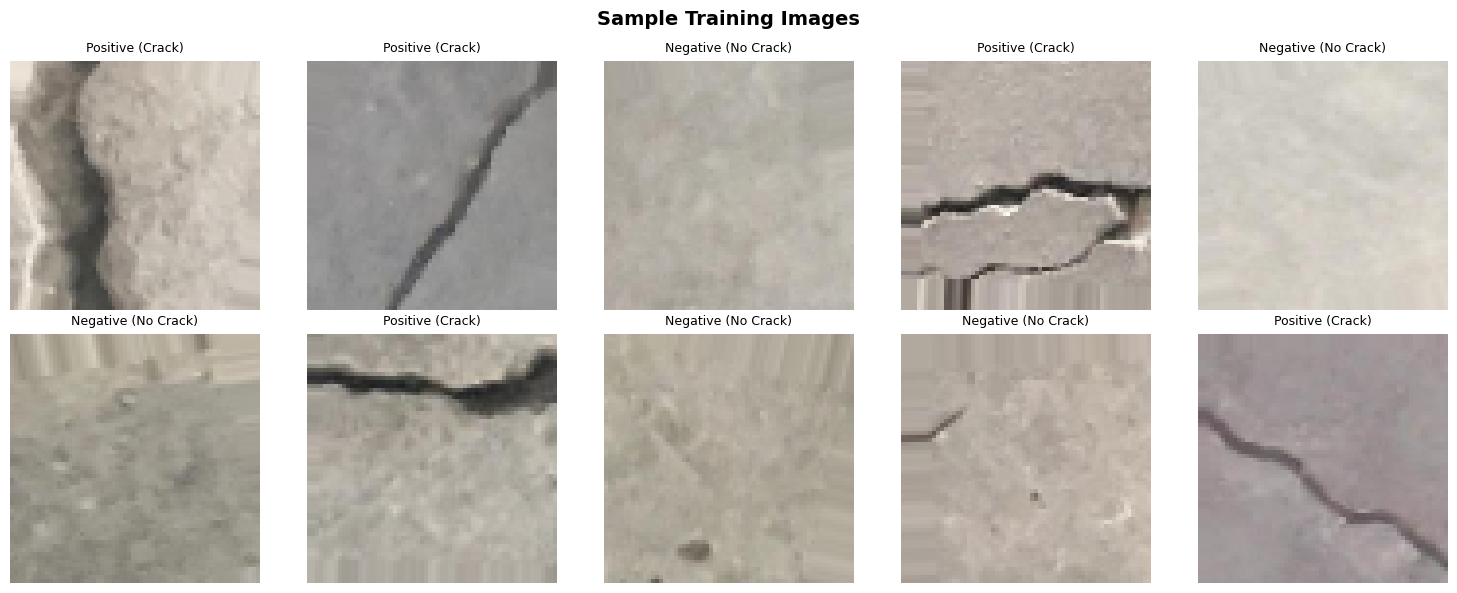

Saved: docs/sample_images.png


In [4]:
import os # Ensure os is imported

sample_imgs, sample_labels = next(train_gen)
class_names = ['Negative (No Crack)', 'Positive (Crack)']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.set_title(class_names[int(sample_labels[i])], fontsize=9)
    ax.axis('off')
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname('../docs/sample_images.png'), exist_ok=True)

plt.savefig('../docs/sample_images.png', dpi=150)
plt.show()
print('Saved: docs/sample_images.png')

In [5]:
# Load MobileNetV2 pretrained on ImageNet, exclude top layers
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze base

# Custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')   # binary output
], name='CrackDetector')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CrackDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,345,153 (8.95 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

print(f'\nBest val accuracy: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9789 - loss: 0.0592
Epoch 1: val_loss improved from None to 0.02270, saving model to ./crack_model.keras

Epoch 1: finished saving model to ./crack_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 95s 77ms/step - accuracy: 0.9887 - loss: 0.0367 - val_accuracy: 0.9937 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 2/10
 136/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9921 - loss: 0.0224

KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Acc',  color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Val Acc',    color='tomato')
ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='royalblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax2.set_title('Model Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Crack Detection — Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/training_curves.png', dpi=150)
plt.show()
print('Saved: docs/training_curves.png')

In [ ]:
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_gen.classes

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['No Crack', 'Crack']))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['No Crack','Crack'])
ax.set_yticklabels(['No Crack','Crack'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Representative dataset for INT8 calibration
def representative_dataset():
    val_gen.reset()
    for _ in range(100):
        imgs, _ = next(val_gen)
        for img in imgs:
            yield [img.reshape(1, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)]

# Convert to TFLite with full INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

original_kb  = os.path.getsize(MODEL_PATH)  / 1024
quantized_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f'Original  model : {original_kb:.1f} KB')
print(f'Quantized model : {quantized_kb:.1f} KB')
print(f'Size reduction  : {original_kb/quantized_kb:.1f}x')
print(f'Saved: {TFLITE_PATH}')

In [ ]:
import os

with open(TFLITE_PATH, 'rb') as f:
    model_bytes = f.read()

model_len = len(model_bytes)

# ── Generate model_params.h ──────────────────────────────
os.makedirs('../riscv_firmware', exist_ok=True)

header_content = f"""/**
 * model_params.h
 * Auto-generated from crack_model_quant.tflite
 * Crack Detection Edge AI — RISC-V SiFive FE310-G002
 * DO NOT EDIT MANUALLY
 */
#ifndef MODEL_PARAMS_H
#define MODEL_PARAMS_H

#include <stdint.h>

#define MODEL_DATA_LEN {model_len}U
#define IMG_SIZE       64
#define IMG_CHANNELS   3
#define NUM_CLASSES    2
#define CRACK_THRESHOLD_INT8  0    /* INT8 midpoint (sigmoid 0.5 maps to ~0) */

/* Labels */
#define LABEL_NO_CRACK 0
#define LABEL_CRACK    1

extern const uint8_t g_model_data[MODEL_DATA_LEN];

#endif /* MODEL_PARAMS_H */
"""

with open(C_HEADER, 'w') as f:
    f.write(header_content)

# ── Generate model_params.c ──────────────────────────────
hex_values = ', '.join(f'0x{b:02x}' for b in model_bytes)
# Wrap at 12 values per line for readability
chunks = [model_bytes[i:i+12] for i in range(0, len(model_bytes), 12)]
hex_lines = ',\n  '.join(', '.join(f'0x{b:02x}' for b in chunk) for chunk in chunks)

source_content = f"""/**
 * model_params.c
 * Auto-generated INT8 quantized model data
 * Crack Detection Edge AI — RISC-V SiFive FE310-G002
 * Model size: {model_len} bytes ({model_len/1024:.1f} KB)
 */
#include "model_params.h"

/* Quantized TFLite flatbuffer stored in Flash (QSPI) */
const uint8_t g_model_data[MODEL_DATA_LEN] = {{
  {hex_lines}
}};
"""

with open(C_SOURCE, 'w') as f:
    f.write(source_content)

print(f'Generated: {C_HEADER}  ({os.path.getsize(C_HEADER)//1024} KB)')
print(f'Generated: {C_SOURCE} ({os.path.getsize(C_SOURCE)//1024} KB)')
print('\n✅ All files ready for RISC-V firmware!')


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

# Pick first validation image
val_gen.reset()
sample_imgs, sample_labels = next(val_gen)
test_img = sample_imgs[0]                          # float32, 0-1, shape (64,64,3)
test_label = int(sample_labels[0])

# Quantize to INT8 (scale same as model input)
test_img_int8 = (test_img * 255 - 128).astype(np.int8)  # zero_point=128, scale=1/255

flat = test_img_int8.flatten()
chunks = [flat[i:i+16] for i in range(0, len(flat), 16)]
hex_lines = ',\n  '.join(', '.join(f'{int(b):4d}' for b in chunk) for chunk in chunks)

test_c = f"""/**
 * test_image.h — Sample input for firmware verification
 * True label: {test_label} ({'Crack' if test_label==1 else 'No Crack'})
 */
#ifndef TEST_IMAGE_H
#define TEST_IMAGE_H
#include <stdint.h>

#define TEST_IMG_TRUE_LABEL {test_label}   /* {'CRACK' if test_label==1 else 'NO_CRACK'} */

static const int8_t g_test_image[64*64*3] = {{
  {hex_lines}
}};

#endif /* TEST_IMAGE_H */
"""

with open('../riscv_firmware/test_image.h', 'w') as f:
    f.write(test_c)

# Save image for docs
plt.figure(figsize=(3,3))
plt.imshow(test_img)
plt.title(f'Test sample: {class_names[test_label]}')
plt.axis('off')
plt.tight_layout()
plt.savefig('../docs/test_sample.png', dpi=150)
plt.show()
print('Generated: riscv_firmware/test_image.h')
print('\n🎉 Pipeline complete! Now open Freedom Studio with the riscv_firmware/ project.')